

**Quy ước nhãn:** `0 = REAL (Tin thật)` | `1 = FAKE (Tin giả)`


## 1️⃣ Cài đặt thư viện

In [ ]:
!pip install -q kagglehub transformers torch pyvi scikit-learn

print("✅ Cài đặt hoàn tất!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 119.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 77.5 MB/s eta 0:00:00
✅ Cài đặt hoàn tất!


## 2️⃣ Cấu hình Kaggle API

In [ ]:

from google.colab import files
import os

print("📤 Upload file kaggle.json...")
uploaded = files.upload()

os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.rename('kaggle.json', os.path.expanduser('~/.kaggle/kaggle.json'))
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
print("✅ Kaggle API đã được cấu hình!")


📤 Upload file kaggle.json...


Saving kaggle.json to kaggle.json
✅ Kaggle API đã được cấu hình!


 Tải & Gộp Dataset

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import unicodedata
from pathlib import Path

DATA_DIR = Path('/content/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)
MERGED_PATH = DATA_DIR / 'merged_datasets.csv'

# ── Nếu đã có file merged từ notebook PhoBERT → dùng lại ──
if MERGED_PATH.exists():
    print(f"✅ Tìm thấy file đã gộp sẵn: {MERGED_PATH}")
    df = pd.read_csv(MERGED_PATH, encoding='utf-8-sig')
    print(f"   Đã load: {len(df):,} mẫu")

# ── Nếu chưa có → tải lại từ Kaggle ──
else:
    print("📥 Chưa có file gộp — Đang tải 4 datasets từ Kaggle...")
    df_list = []

    # Dataset 1
    try:
        path1 = kagglehub.dataset_download("phngnguynthu1803/vietnamese-fake-news-dataset")
        for file in sorted(os.listdir(path1)):
            if not file.endswith('.csv'): continue
            try:
                temp = pd.read_csv(os.path.join(path1, file), encoding='utf-8')
                temp.rename(columns={'news': 'text', 'content': 'text'}, inplace=True)
                if 'real' in file.lower():   temp['label'] = 0
                elif 'fake' in file.lower(): temp['label'] = 1
                else:
                    print(f"   ⚠️ Bỏ qua '{file}' — không xác định nhãn")
                    continue
                if 'text' in temp.columns:
                    df_list.append(temp[['text', 'label']].dropna())
                    print(f"   ✅ DS1/{file}: {len(temp):,} mẫu")
            except: pass
    except Exception as e: print(f"❌ DS1: {e}")

    # Dataset 2
    try:
        path2 = kagglehub.dataset_download("chuynvinquc/fakenewvn")
        for fname in [f for f in os.listdir(path2) if f.endswith('.csv')]:
            temp = pd.read_csv(os.path.join(path2, fname), encoding='utf-8')
            temp.rename(columns={'post_message': 'text'}, inplace=True)
            if 'text' in temp.columns and 'label' in temp.columns:
                temp['label'] = pd.to_numeric(temp['label'], errors='coerce')
                temp.dropna(subset=['label'], inplace=True)
                temp['label'] = temp['label'].astype(int)
                df_list.append(temp[['text', 'label']])
                print(f"   ✅ DS2/{fname}: {len(temp):,} mẫu")
    except Exception as e: print(f"❌ DS2: {e}")

    # Dataset 3
    try:
        path3 = kagglehub.dataset_download("goumanguyen/vietnamese-fake-news-dataset-pbl7")
        for root, _, files in os.walk(path3):
            for file in sorted(files):
                if not file.endswith('.csv'): continue
                try:
                    temp = pd.read_csv(os.path.join(root, file), encoding='utf-8')
                    temp.rename(columns={'Maintext':'text','maintext':'text','Label':'label'}, inplace=True)
                    if 'text' in temp.columns and 'label' in temp.columns:
                        if temp['label'].dtype == object:
                            temp['label'] = temp['label'].map(
                                {'Real':0,'real':0,'Fake':1,'fake':1,'TIN THẬT':0,'TIN GIẢ':1})
                        temp['label'] = pd.to_numeric(temp['label'], errors='coerce')
                        temp.dropna(subset=['label','text'], inplace=True)
                        temp['label'] = temp['label'].astype(int)
                        df_list.append(temp[['text','label']])
                        print(f"   ✅ DS3/{file}: {len(temp):,} mẫu")
                except: pass
    except Exception as e: print(f"❌ DS3: {e}")

    # Dataset 4
    try:
        path4 = kagglehub.dataset_download("leviettrieu369/vietnamese-medical-fake-news-dataset")
        for fname in [f for f in os.listdir(path4) if f.endswith('.csv')]:
            temp = pd.read_csv(os.path.join(path4, fname), encoding='utf-8')
            temp.rename(columns={'normalized_content':'text','is_fake':'label'}, inplace=True)
            if 'label' in temp.columns and 'text' in temp.columns:
                bool_map = {True:1,False:0,'True':1,'False':0,'TRUE':1,'FALSE':0,1:1,0:0}
                temp['label'] = temp['label'].map(bool_map)
                temp.dropna(subset=['label','text'], inplace=True)
                temp['label'] = temp['label'].astype(int)
                df_list.append(temp[['text','label']])
                print(f"   ✅ DS4/{fname}: {len(temp):,} mẫu")
    except Exception as e: print(f"❌ DS4: {e}")

    # Gộp & làm sạch
    df_raw = pd.concat(df_list, ignore_index=True)
    df_raw['text'] = df_raw['text'].apply(lambda x: unicodedata.normalize('NFC', str(x)))
    df_raw.drop_duplicates(subset=['text'], keep='first', inplace=True)
    df_raw = df_raw[df_raw['text'].str.len() >= 30]
    df_raw = df_raw[df_raw['label'].isin([0, 1])]
    df = df_raw.sample(frac=1, random_state=42).reset_index(drop=True)

    df.to_csv(MERGED_PATH, index=False, encoding='utf-8-sig')
    print(f"\n💾 Đã lưu: {MERGED_PATH}")

# ── Thống kê tổng quan ──
counts = df['label'].value_counts().sort_index()
print("\n" + "="*55)
print("📊 THỐNG KÊ DATASET CHUNG")
print("="*55)
print(f"  Tổng mẫu         : {len(df):,}")
print(f"  Tin thật (0)     : {counts.get(0,0):,}  ({counts.get(0,0)/len(df)*100:.1f}%)")
print(f"  Tin giả  (1)     : {counts.get(1,0):,}  ({counts.get(1,0)/len(df)*100:.1f}%)")
print("="*55)
print("✅ Dataset sẵn sàng cho cả 4 mô hình!")


📥 Chưa có file gộp — Đang tải 4 datasets từ Kaggle...
Using Colab cache for faster access to the 'vietnamese-fake-news-dataset' dataset.
   ✅ DS1/real_news.csv: 3,523 mẫu
   ✅ DS1/real_news_5500_balanced.csv: 4,175 mẫu
Using Colab cache for faster access to the 'fakenewvn' dataset.
   ✅ DS2/public_train.csv: 4,372 mẫu
Using Colab cache for faster access to the 'vietnamese-fake-news-dataset-pbl7' dataset.
   ✅ DS3/fix_test_data.csv: 161 mẫu
   ✅ DS3/update_train_data.csv: 849 mẫu
   ✅ DS3/update_val_data.csv: 171 mẫu
   ✅ DS3/fix_test_data.csv: 161 mẫu
   ✅ DS3/train_data.csv: 683 mẫu
   ✅ DS3/val_data.csv: 171 mẫu
Using Colab cache for faster access to the 'vietnamese-medical-fake-news-dataset' dataset.
   ✅ DS4/full_dataset.csv: 10,617 mẫu

💾 Đã lưu: /content/data/merged_datasets.csv

📊 THỐNG KÊ DATASET CHUNG
  Tổng mẫu         : 22,054
  Tin thật (0)     : 15,886  (72.0%)
  Tin giả  (1)     : 6,168  (28.0%)
✅ Dataset sẵn sàng cho cả 4 mô hình!


In [ ]:
# ==============================================================
# BIEU DO PHAN BO DATASET - compare_4_models.ipynb
# Nguon: 4 bo du lieu tieng Viet tu Kaggle (gop tu nhien)
# Nhan: 0 = Real (Tin that), 1 = Fake (Tin gia)
# ==============================================================
import matplotlib.pyplot as plt
import numpy as np

label_counts = df["label"].value_counts().sort_index()
real_count = int(label_counts.get(0, 0))
fake_count = int(label_counts.get(1, 0))
total      = real_count + fake_count
real_pct   = real_count / total * 100
fake_pct   = fake_count / total * 100

COLOR_REAL = "#2196F3"
COLOR_FAKE = "#F44336"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "Phan bo Dataset — compare_4_models.ipynb\n"
    "(Du lieu Tieng Viet | Mat can bang TU NHIEN tu 4 nguon Kaggle)",
    fontsize=13, fontweight="bold", y=1.03
)

# --- 1. Bar chart ---
bars = axes[0].bar(
    ["Real (0)\nTin that", "Fake (1)\nTin gia"],
    [real_count, fake_count],
    color=[COLOR_REAL, COLOR_FAKE],
    edgecolor="black", alpha=0.85, width=0.5
)
for bar, val, pct in zip(bars, [real_count, fake_count], [real_pct, fake_pct]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{val:,}\n({pct:.1f}%)",
        ha="center", va="bottom", fontsize=11, fontweight="bold"
    )
axes[0].set_title("So luong mau theo nhan", fontsize=12, fontweight="bold")
axes[0].set_ylabel("So luong mau")
axes[0].set_ylim(0, max(real_count, fake_count) * 1.22)
axes[0].grid(axis="y", alpha=0.4, linestyle="--")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

# --- 2. Pie chart ---
wedges, texts, autotexts = axes[1].pie(
    [real_count, fake_count],
    labels=["Real (0)\nTin that", "Fake (1)\nTin gia"],
    autopct="%1.1f%%",
    colors=[COLOR_REAL, COLOR_FAKE],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.60,
    textprops={"fontsize": 11}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight("bold")
axes[1].set_title("Ti le phan tram", fontsize=12, fontweight="bold")

# --- 3. Horizontal stacked bar ---
axes[2].barh([0], [real_pct], color=COLOR_REAL, alpha=0.88)
axes[2].barh([0], [fake_pct], left=[real_pct], color=COLOR_FAKE, alpha=0.88, hatch="//")
axes[2].set_xlim(0, 100)
axes[2].set_yticks([])
axes[2].set_xlabel("Ti le (%)", fontsize=11)
axes[2].set_title("Thanh phan phan bo (%)", fontsize=12, fontweight="bold")
axes[2].text(real_pct / 2, 0, f"{real_pct:.1f}%\n{real_count:,}",
             ha="center", va="center", fontsize=12, fontweight="bold", color="white")
axes[2].text(real_pct + fake_pct / 2, 0, f"{fake_pct:.1f}%\n{fake_count:,}",
             ha="center", va="center", fontsize=12, fontweight="bold", color="white")
from matplotlib.patches import Patch
axes[2].legend(
    handles=[Patch(color=COLOR_REAL, label=f"Real: {real_count:,} ({real_pct:.1f}%)"),
             Patch(color=COLOR_FAKE, label=f"Fake: {fake_count:,} ({fake_pct:.1f}%)", hatch="//")],
    loc="lower center", bbox_to_anchor=(0.5, -0.30), fontsize=10, frameon=False
)

print("=" * 55)
print("THONG KE PHAN BO DATASET")
print(f"  Tong mau     : {total:,}")
print(f"  Real (0)     : {real_count:,}  ({real_pct:.1f}%)")
print(f"  Fake (1)     : {fake_count:,}  ({fake_pct:.1f}%)")
print(f"  Nguon        : 4 datasets Kaggle (Tieng Viet)")
print(f"  Loai mat CB  : TU NHIEN (gop nhieu nguon)")
print("=" * 55)

plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Tiền xử lý & Chia tập dữ liệu (dùng chung)

In [ ]:
import re
import string
import unicodedata
from pyvi import ViTokenizer
from sklearn.model_selection import train_test_split

print("="*55)
print("🔤 TIỀN XỬ LÝ VĂN BẢN TIẾNG VIỆT")
print("="*55)

def clean_text(text: str) -> str:
    """
    Làm sạch văn bản — dùng cho RF và SVM (TF-IDF không cần tách từ).
    """
    text = unicodedata.normalize('NFC', str(text)).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def clean_and_segment(text: str) -> str:
    """
    Làm sạch + tách từ tiếng Việt — dùng cho LSTM và PhoBERT.
    ViTokenizer: 'học sinh' → 'học_sinh'
    """
    text = clean_text(text)
    return ViTokenizer.tokenize(text)

# Áp dụng cả 2 dạng tiền xử lý
print("⏳ Đang xử lý văn bản (có thể mất vài phút)...")
df['text_clean']    = df['text'].apply(clean_text)          # cho RF, SVM
df['text_segmented'] = df['text'].apply(clean_and_segment)  # cho LSTM, PhoBERT

# Loại dòng rỗng sau xử lý
df = df[df['text_clean'].str.len() > 5].reset_index(drop=True)
print(f"✅ Còn lại: {len(df):,} mẫu sau tiền xử lý")

# ── Chia Train / Val / Test (70 / 15 / 15) ──
# stratify=y đảm bảo tỉ lệ nhãn đồng đều ở cả 3 tập
X_raw  = df['text_clean'].values
X_seg  = df['text_segmented'].values
y      = df['label'].values

X_raw_temp,  X_raw_test,  y_temp, y_test  = train_test_split(
    X_raw, y, test_size=0.15, random_state=42, stratify=y)
X_seg_temp,  X_seg_test,  _,      _       = train_test_split(
    X_seg, y, test_size=0.15, random_state=42, stratify=y)

X_raw_train, X_raw_val, y_train, y_val = train_test_split(
    X_raw_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)
X_seg_train, X_seg_val, _,       _     = train_test_split(
    X_seg_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

total = len(y)
print("\n✂️  CHIA TẬP (70% Train | 15% Val | 15% Test)")
print(f"   Train : {len(y_train):,} mẫu ({len(y_train)/total*100:.1f}%)")
print(f"   Val   : {len(y_val):,} mẫu ({len(y_val)/total*100:.1f}%)")
print(f"   Test  : {len(y_test):,} mẫu ({len(y_test)/total*100:.1f}%)")
print("\n✅ Tất cả 4 mô hình sẽ dùng chung cách chia này!")


🔤 TIỀN XỬ LÝ VĂN BẢN TIẾNG VIỆT
⏳ Đang xử lý văn bản (có thể mất vài phút)...
✅ Còn lại: 22,054 mẫu sau tiền xử lý

✂️  CHIA TẬP (70% Train | 15% Val | 15% Test)
   Train : 15,445 mẫu (70.0%)
   Val   : 3,300 mẫu (15.0%)
   Test  : 3,309 mẫu (15.0%)

✅ Tất cả 4 mô hình sẽ dùng chung cách chia này!


Vectorization — TF-IDF (cho Random Forest & SVM)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

print("="*55)
print("📐 TF-IDF VECTORIZATION")
print("="*55)
print("""
TF-IDF chuyển văn bản → vector số:
  TF  = tần suất từ trong văn bản
  IDF = độ hiếm của từ trong toàn bộ corpus
  → Từ quan trọng & hiếm sẽ có trọng số cao hơn
""")

# TF-IDF với n-gram (1,2) để bắt thêm cụm 2 từ
# sublinear_tf=True: dùng log(tf) thay vì tf thô
tfidf = TfidfVectorizer(
    max_features=50000,    # Giữ 50k từ phổ biến nhất
    ngram_range=(1, 2),    # Unigram + Bigram
    sublinear_tf=True,     # log(1+tf) — giảm ảnh hưởng từ lặp nhiều
    min_df=2,              # Bỏ từ xuất hiện < 2 lần
    analyzer='word'
)

# Chỉ fit trên tập train — tránh data leakage
X_tfidf_train = tfidf.fit_transform(X_raw_train)
X_tfidf_val   = tfidf.transform(X_raw_val)
X_tfidf_test  = tfidf.transform(X_raw_test)

print(f"✅ TF-IDF Matrix:")
print(f"   Vocab size : {len(tfidf.vocabulary_):,} features")
print(f"   Train shape: {X_tfidf_train.shape}")
print(f"   Val shape  : {X_tfidf_val.shape}")
print(f"   Test shape : {X_tfidf_test.shape}")
print(f"   Sparsity   : {1 - X_tfidf_train.nnz / (X_tfidf_train.shape[0]*X_tfidf_train.shape[1]):.4f}")


📐 TF-IDF VECTORIZATION

TF-IDF chuyển văn bản → vector số:
  TF  = tần suất từ trong văn bản
  IDF = độ hiếm của từ trong toàn bộ corpus
  → Từ quan trọng & hiếm sẽ có trọng số cao hơn

✅ TF-IDF Matrix:
   Vocab size : 50,000 features
   Train shape: (15445, 50000)
   Val shape  : (3300, 50000)
   Test shape : (3309, 50000)
   Sparsity   : 0.9921


Mô hình 1 — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

print("="*55)
print("🌲 RANDOM FOREST")
print("="*55)
print("""
Random Forest = tập hợp nhiều cây quyết định (Decision Tree).
Mỗi cây được train trên subset ngẫu nhiên của dữ liệu.
Kết quả cuối = vote đa số từ tất cả cây.
Ưu điểm: Ít overfit, dễ giải thích, nhanh.
""")

# ── Khởi tạo và train ──
print("⏳ Đang train Random Forest...")
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,       # 200 cây — cân bằng tốc độ và độ chính xác
    max_depth=None,         # Không giới hạn độ sâu
    min_samples_split=5,    # Node cần ít nhất 5 mẫu để chia
    class_weight='balanced',# Tự động cân bằng nhãn mất cân bằng
    random_state=42,
    n_jobs=-1               # Dùng tất cả CPU core
)

rf_model.fit(X_tfidf_train, y_train)
rf_train_time = time.time() - t0
print(f"✅ Train xong trong {rf_train_time:.1f}s")

# ── Đánh giá ──
rf_preds_val  = rf_model.predict(X_tfidf_val)
rf_preds_test = rf_model.predict(X_tfidf_test)

rf_val_acc  = accuracy_score(y_val,  rf_preds_val)
rf_val_f1   = f1_score(y_val,  rf_preds_val,  average='macro')
rf_test_acc = accuracy_score(y_test, rf_preds_test)
rf_test_f1  = f1_score(y_test, rf_preds_test, average='macro')

print(f"\n📊 KẾT QUẢ RANDOM FOREST:")
print(f"   Val  Accuracy : {rf_val_acc:.4f}  |  Val  F1: {rf_val_f1:.4f}")
print(f"   Test Accuracy : {rf_test_acc:.4f}  |  Test F1: {rf_test_f1:.4f}")
print(f"\n📋 Classification Report (Test Set):")
print(classification_report(y_test, rf_preds_test,
      target_names=['REAL (0)', 'FAKE (1)'], digits=4))

# ── Top features quan trọng nhất ──
feature_names = tfidf.get_feature_names_out()
importances   = rf_model.feature_importances_
top_idx       = importances.argsort()[-15:][::-1]
print("🔑 Top 15 từ quan trọng nhất (Random Forest):")
for i, idx in enumerate(top_idx):
    print(f"   {i+1:2d}. '{feature_names[idx]}' ({importances[idx]:.4f})")


🌲 RANDOM FOREST

Random Forest = tập hợp nhiều cây quyết định (Decision Tree).
Mỗi cây được train trên subset ngẫu nhiên của dữ liệu.
Kết quả cuối = vote đa số từ tất cả cây.
Ưu điểm: Ít overfit, dễ giải thích, nhanh.

⏳ Đang train Random Forest...
✅ Train xong trong 55.7s

📊 KẾT QUẢ RANDOM FOREST:
   Val  Accuracy : 0.9167  |  Val  F1: 0.8895
   Test Accuracy : 0.9205  |  Test F1: 0.8947

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

    REAL (0)     0.9138    0.9824    0.9468      2384
    FAKE (1)     0.9437    0.7611    0.8426       925

    accuracy                         0.9205      3309
   macro avg     0.9287    0.8717    0.8947      3309
weighted avg     0.9221    0.9205    0.9177      3309

🔑 Top 15 từ quan trọng nhất (Random Forest):
    1. 'có thể' (0.0107)
    2. 'có' (0.0071)
    3. 'và' (0.0055)
    4. 'của' (0.0055)
    5. 'bệnh' (0.0050)
    6. 'thể' (0.0046)
    7. 'là' (0.0043)
    8. 'cho biết' (0.0043)
    9. 'đau' (0.0

 Mô hình 2 — SVM (Support Vector Machine)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

print("="*55)
print("📏 SVM (Support Vector Machine)")
print("="*55)
print("""
SVM tìm siêu phẳng (hyperplane) tối ưu để phân tách 2 lớp.
LinearSVC phù hợp với dữ liệu TF-IDF chiều cao (sparse).
Ưu điểm: Hiệu quả cao với văn bản, ít hyperparameter.
""")

print("⏳ Đang train SVM...")
t0 = time.time()

# LinearSVC nhanh hơn SVC kernel RBF với dữ liệu text chiều cao
# CalibratedClassifierCV để lấy xác suất (predict_proba)
svm_base = LinearSVC(
    C=1.0,               # Hệ số regularization
    max_iter=2000,       # Tăng lên nếu báo ConvergenceWarning
    class_weight='balanced',
    random_state=42
)
svm_model = CalibratedClassifierCV(svm_base, cv=3)
svm_model.fit(X_tfidf_train, y_train)
svm_train_time = time.time() - t0
print(f"✅ Train xong trong {svm_train_time:.1f}s")

# ── Đánh giá ──
svm_preds_val  = svm_model.predict(X_tfidf_val)
svm_preds_test = svm_model.predict(X_tfidf_test)

svm_val_acc  = accuracy_score(y_val,  svm_preds_val)
svm_val_f1   = f1_score(y_val,  svm_preds_val,  average='macro')
svm_test_acc = accuracy_score(y_test, svm_preds_test)
svm_test_f1  = f1_score(y_test, svm_preds_test, average='macro')

print(f"\n📊 KẾT QUẢ SVM:")
print(f"   Val  Accuracy : {svm_val_acc:.4f}  |  Val  F1: {svm_val_f1:.4f}")
print(f"   Test Accuracy : {svm_test_acc:.4f}  |  Test F1: {svm_test_f1:.4f}")
print(f"\n📋 Classification Report (Test Set):")
print(classification_report(y_test, svm_preds_test,
      target_names=['REAL (0)', 'FAKE (1)'], digits=4))


📏 SVM (Support Vector Machine)

SVM tìm siêu phẳng (hyperplane) tối ưu để phân tách 2 lớp.
LinearSVC phù hợp với dữ liệu TF-IDF chiều cao (sparse).
Ưu điểm: Hiệu quả cao với văn bản, ít hyperparameter.

⏳ Đang train SVM...
✅ Train xong trong 1.5s

📊 KẾT QUẢ SVM:
   Val  Accuracy : 0.9427  |  Val  F1: 0.9276
   Test Accuracy : 0.9477  |  Test F1: 0.9341

📋 Classification Report (Test Set):
              precision    recall  f1-score   support

    REAL (0)     0.9548    0.9736    0.9641      2384
    FAKE (1)     0.9282    0.8811    0.9040       925

    accuracy                         0.9477      3309
   macro avg     0.9415    0.9273    0.9341      3309
weighted avg     0.9473    0.9477    0.9473      3309



 Mô hình 3 — LSTM (Long Short-Term Memory)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from sklearn.metrics import classification_report, accuracy_score, f1_score
from collections import Counter
import time
import numpy as np

print("="*55)
print("🔁 LSTM (Long Short-Term Memory)")
print("="*55)
print("""
LSTM là mạng nơ-ron hồi quy (RNN) có khả năng ghi nhớ
ngữ cảnh dài hạn trong câu.
Ưu điểm so với RF/SVM: Hiểu thứ tự từ và ngữ cảnh.
Nhược điểm so với PhoBERT: Không có pretrained weights.
""")

# ── CONFIG ──
VOCAB_SIZE  = 30000   # Giữ 30k từ phổ biến nhất
EMBED_DIM   = 128     # Kích thước embedding
HIDDEN_DIM  = 256     # Kích thước hidden state LSTM
NUM_LAYERS  = 2       # Số lớp LSTM chồng nhau
DROPOUT     = 0.3     # Dropout để tránh overfit
MAX_SEQ_LEN = 200     # Độ dài tối đa chuỗi token
BATCH_SIZE  = 64
EPOCHS_LSTM = 5
LR_LSTM     = 1e-3

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️  Thiết bị: {device}")

# ── Xây dựng từ điển (Vocabulary) ──
print("\n⏳ Đang xây dựng từ điển...")
all_words = []
for text in X_seg_train:
    all_words.extend(text.split())

word_freq  = Counter(all_words)
vocab      = ['<PAD>', '<UNK>'] + [w for w, f in word_freq.most_common(VOCAB_SIZE - 2)]
word2idx   = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f"✅ Từ điển: {VOCAB_SIZE:,} từ")

def text_to_ids(text, max_len=MAX_SEQ_LEN):
    """Chuyển văn bản → danh sách index, padding/truncate đến max_len."""
    ids = [word2idx.get(w, 1) for w in text.split()]  # 1 = <UNK>
    if len(ids) < max_len:
        ids = ids + [0] * (max_len - len(ids))         # 0 = <PAD>
    return ids[:max_len]

# ── Dataset class ──
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.X = [text_to_ids(t) for t in texts]
        self.y = labels

    def __len__(self): return len(self.y)

    def __getitem__(self, i):
        return (torch.tensor(self.X[i], dtype=torch.long),
                torch.tensor(self.y[i], dtype=torch.long))

train_dl = DataLoader(TextDataset(X_seg_train, y_train),
                      batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(TextDataset(X_seg_val,   y_val),
                      batch_size=BATCH_SIZE)
test_dl  = DataLoader(TextDataset(X_seg_test,  y_test),
                      batch_size=BATCH_SIZE)

# ── Kiến trúc LSTM ──
class LSTMClassifier(nn.Module):
    """
    Mô hình LSTM 2 chiều (Bidirectional) cho phân loại văn bản.
    Embedding → BiLSTM → Dropout → Linear → Output (2 nhãn)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        # Embedding layer: chuyển index → vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Bidirectional LSTM: đọc chuỗi từ 2 chiều → hiểu ngữ cảnh tốt hơn
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,   # Forward + Backward
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        # hidden_dim * 2 vì bidirectional
        self.fc = nn.Linear(hidden_dim * 2, 2)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, (hidden, _) = self.lstm(embedded)
        # Lấy hidden state của layer cuối (forward + backward)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

lstm_model = LSTMClassifier(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM,
                              NUM_LAYERS, DROPOUT).to(device)
optimizer_lstm = Adam(lstm_model.parameters(), lr=LR_LSTM)
criterion      = nn.CrossEntropyLoss()

total_params = sum(p.numel() for p in lstm_model.parameters())
print(f"✅ LSTM model: {total_params:,} tham số")

# ── Training loop ──
lstm_history = {'train_acc': [], 'val_acc': [], 'val_f1': []}
best_lstm_f1   = 0.0
best_lstm_path = '/content/data/lstm_best.pt'

print(f"\n🚀 Bắt đầu training LSTM ({EPOCHS_LSTM} epochs)...")

for epoch in range(1, EPOCHS_LSTM + 1):
    t0 = time.time()

    # Train
    lstm_model.train()
    correct, total_n, total_loss = 0, 0, 0.0
    for X_batch, y_batch in train_dl:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer_lstm.zero_grad()
        logits = lstm_model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer_lstm.step()
        preds    = torch.argmax(logits, dim=1)
        correct += (preds == y_batch).sum().item()
        total_n += y_batch.size(0)
        total_loss += loss.item()
    train_acc = correct / total_n

    # Validate
    lstm_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_dl:
            preds = torch.argmax(lstm_model(X_batch.to(device)), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds, average='macro')

    lstm_history['train_acc'].append(train_acc)
    lstm_history['val_acc'].append(val_acc)
    lstm_history['val_f1'].append(val_f1)

    elapsed = time.time() - t0
    saved   = ''
    if val_f1 > best_lstm_f1:
        best_lstm_f1 = val_f1
        torch.save(lstm_model.state_dict(), best_lstm_path)
        saved = ' 💾 Best saved!'

    print(f"  Epoch {epoch}/{EPOCHS_LSTM} | {elapsed:.0f}s | "
          f"Loss={total_loss/len(train_dl):.4f} | "
          f"TrainAcc={train_acc:.4f} | ValAcc={val_acc:.4f} | "
          f"ValF1={val_f1:.4f}{saved}")

# ── Đánh giá trên Test ──
lstm_model.load_state_dict(torch.load(best_lstm_path))
lstm_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_dl:
        preds = torch.argmax(lstm_model(X_batch.to(device)), dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

lstm_test_acc = accuracy_score(all_labels, all_preds)
lstm_test_f1  = f1_score(all_labels, all_preds, average='macro')
lstm_preds_test = all_preds

print(f"\n📊 KẾT QUẢ LSTM (Test Set):")
print(f"   Test Accuracy : {lstm_test_acc:.4f}")
print(f"   Test F1 (macro): {lstm_test_f1:.4f}")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, lstm_preds_test,
      target_names=['REAL (0)', 'FAKE (1)'], digits=4))


🔁 LSTM (Long Short-Term Memory)

LSTM là mạng nơ-ron hồi quy (RNN) có khả năng ghi nhớ
ngữ cảnh dài hạn trong câu.
Ưu điểm so với RF/SVM: Hiểu thứ tự từ và ngữ cảnh.
Nhược điểm so với PhoBERT: Không có pretrained weights.


🖥️  Thiết bị: cuda

⏳ Đang xây dựng từ điển...
✅ Từ điển: 30,000 từ
✅ LSTM model: 6,208,514 tham số

🚀 Bắt đầu training LSTM (5 epochs)...
  Epoch 1/5 | 21s | Loss=0.4625 | TrainAcc=0.7877 | ValAcc=0.8512 | ValF1=0.8015 💾 Best saved!
  Epoch 2/5 | 21s | Loss=0.3563 | TrainAcc=0.8530 | ValAcc=0.8718 | ValF1=0.8309 💾 Best saved!
  Epoch 3/5 | 21s | Loss=0.3030 | TrainAcc=0.8780 | ValAcc=0.8655 | ValF1=0.8153
  Epoch 4/5 | 21s | Loss=0.2438 | TrainAcc=0.9029 | ValAcc=0.8873 | ValF1=0.8567 💾 Best saved!
  Epoch 5/5 | 21s | Loss=0.2178 | TrainAcc=0.9158 | ValAcc=0.8891 | ValF1=0.8592 💾 Best saved!

📊 KẾT QUẢ LSTM (Test Set):
   Test Accuracy : 0.8843
   Test F1 (macro): 0.8535

📋 Classification Report:
              precision    recall  f1-score   support

    REAL (0)  

Mô hình 4 — PhoBERT

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score, f1_score
import time

print("="*55)
print("🤗 PHOBERT (VinAI)")
print("="*55)
print("""
PhoBERT = BERT được pre-train trên 20GB văn bản tiếng Việt.
Hiểu sâu ngữ nghĩa, ngữ cảnh 2 chiều.
Thường đạt accuracy cao nhất trong 4 mô hình.
""")

PHOBERT_NAME  = "vinai/phobert-base"
MAX_LEN_BERT  = 256
BATCH_BERT    = 16
EPOCHS_BERT   = 3
LR_BERT       = 2e-5

# ── Dataset ──
class BertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts, self.labels = texts, labels
        self.tokenizer, self.max_len = tokenizer, max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            str(self.texts[i]),
            max_length=self.max_len, padding='max_length',
            truncation=True, return_attention_mask=True,
            return_token_type_ids=False, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(int(self.labels[i]), dtype=torch.long)
        }

tokenizer_bert = AutoTokenizer.from_pretrained(PHOBERT_NAME)

train_bert = DataLoader(BertDataset(X_seg_train, y_train, tokenizer_bert, MAX_LEN_BERT),
                        batch_size=BATCH_BERT, shuffle=True, num_workers=2, pin_memory=True)
val_bert   = DataLoader(BertDataset(X_seg_val,   y_val,   tokenizer_bert, MAX_LEN_BERT),
                        batch_size=BATCH_BERT, num_workers=2, pin_memory=True)
test_bert  = DataLoader(BertDataset(X_seg_test,  y_test,  tokenizer_bert, MAX_LEN_BERT),
                        batch_size=BATCH_BERT, num_workers=2, pin_memory=True)

# ── Model & Optimizer ──
bert_model = AutoModelForSequenceClassification.from_pretrained(
    PHOBERT_NAME, num_labels=2).to(device)
optimizer_bert = AdamW(bert_model.parameters(), lr=LR_BERT, weight_decay=0.01)

total_steps  = len(train_bert) * EPOCHS_BERT
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=total_steps // 10,
    num_training_steps=total_steps
)

bert_history  = {'train_acc': [], 'val_acc': [], 'val_f1': []}
best_bert_f1  = 0.0
BERT_SAVE_PATH = '/content/data/phobert_best_model'

print(f"\n🚀 Bắt đầu training PhoBERT ({EPOCHS_BERT} epochs)...")

for epoch in range(1, EPOCHS_BERT + 1):
    t0 = time.time()

    # Train
    bert_model.train()
    correct, total_n, total_loss = 0, 0, 0.0
    for batch in train_bert:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labs = batch['labels'].to(device)
        optimizer_bert.zero_grad()
        out  = bert_model(input_ids=ids, attention_mask=mask, labels=labs)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)
        optimizer_bert.step()
        scheduler_bert.step()
        preds    = torch.argmax(out.logits, dim=1)
        correct += (preds == labs).sum().item()
        total_n += labs.size(0)
        total_loss += out.loss.item()
    train_acc = correct / total_n

    # Validate
    bert_model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_bert:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            preds = torch.argmax(
                bert_model(input_ids=ids, attention_mask=mask).logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].numpy())
    val_acc = accuracy_score(all_labels, all_preds)
    val_f1  = f1_score(all_labels, all_preds, average='macro')

    bert_history['train_acc'].append(train_acc)
    bert_history['val_acc'].append(val_acc)
    bert_history['val_f1'].append(val_f1)

    elapsed = time.time() - t0
    saved   = ''
    if val_f1 > best_bert_f1:
        best_bert_f1 = val_f1
        bert_model.save_pretrained(BERT_SAVE_PATH)
        tokenizer_bert.save_pretrained(BERT_SAVE_PATH)
        saved = ' 💾 Best saved!'

    print(f"  Epoch {epoch}/{EPOCHS_BERT} | {elapsed:.0f}s | "
          f"Loss={total_loss/len(train_bert):.4f} | "
          f"TrainAcc={train_acc:.4f} | ValAcc={val_acc:.4f} | "
          f"ValF1={val_f1:.4f}{saved}")

# ── Đánh giá trên Test ──
best_bert = AutoModelForSequenceClassification.from_pretrained(BERT_SAVE_PATH).to(device)
best_bert.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_bert:
        ids  = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        preds = torch.argmax(
            best_bert(input_ids=ids, attention_mask=mask).logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['labels'].numpy())

bert_test_acc  = accuracy_score(all_labels, all_preds)
bert_test_f1   = f1_score(all_labels, all_preds, average='macro')
bert_preds_test = all_preds

print(f"\n📊 KẾT QUẢ PHOBERT (Test Set):")
print(f"   Test Accuracy  : {bert_test_acc:.4f}")
print(f"   Test F1 (macro): {bert_test_f1:.4f}")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, bert_preds_test,
      target_names=['REAL (0)', 'FAKE (1)'], digits=4))


🤗 PHOBERT (VinAI)

PhoBERT = BERT được pre-train trên 20GB văn bản tiếng Việt.
Hiểu sâu ngữ nghĩa, ngữ cảnh 2 chiều.
Thường đạt accuracy cao nhất trong 4 mô hình.



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

...

  Epoch 1/3 | 759s | Loss=0.3075 | TrainAcc=0.8704 | ValAcc=0.9248 | ValF1=0.9028 💾 Best saved!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Epoch 2/3 | 764s | Loss=0.1674 | TrainAcc=0.9461 | ValAcc=0.9455 | ValF1=0.9314 💾 Best saved!
  Epoch 3/3 | 765s | Loss=0.1022 | TrainAcc=0.9710 | ValAcc=0.9445 | ValF1=0.9303


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


📊 KẾT QUẢ PHOBERT (Test Set):
   Test Accuracy  : 0.9447
   Test F1 (macro): 0.9300

📋 Classification Report:
              precision    recall  f1-score   support

    REAL (0)     0.9508    0.9736    0.9621      2384
    FAKE (1)     0.9274    0.8703    0.8979       925

    accuracy                         0.9447      3309
   macro avg     0.9391    0.9219    0.9300      3309
weighted avg     0.9443    0.9447    0.9441      3309



 So sánh 4 Mô hình — Kết quả cuối cùng

🏆 BẢNG SO SÁNH 4 MÔ HÌNH TRÊN TEST SET

Mô hình            Accuracy  Precision     Recall   F1 Macro    F1 Fake
─────────────────────────────────────────────────────────────────
  Random Forest      0.9205     0.9287     0.8717     0.8947     0.8426
  SVM                0.9477     0.9415     0.9273     0.9341     0.9040 ⭐
  LSTM               0.8843     0.8610     0.8469     0.8535     0.7864
  PhoBERT            0.9447     0.9391     0.9219     0.9300     0.8979


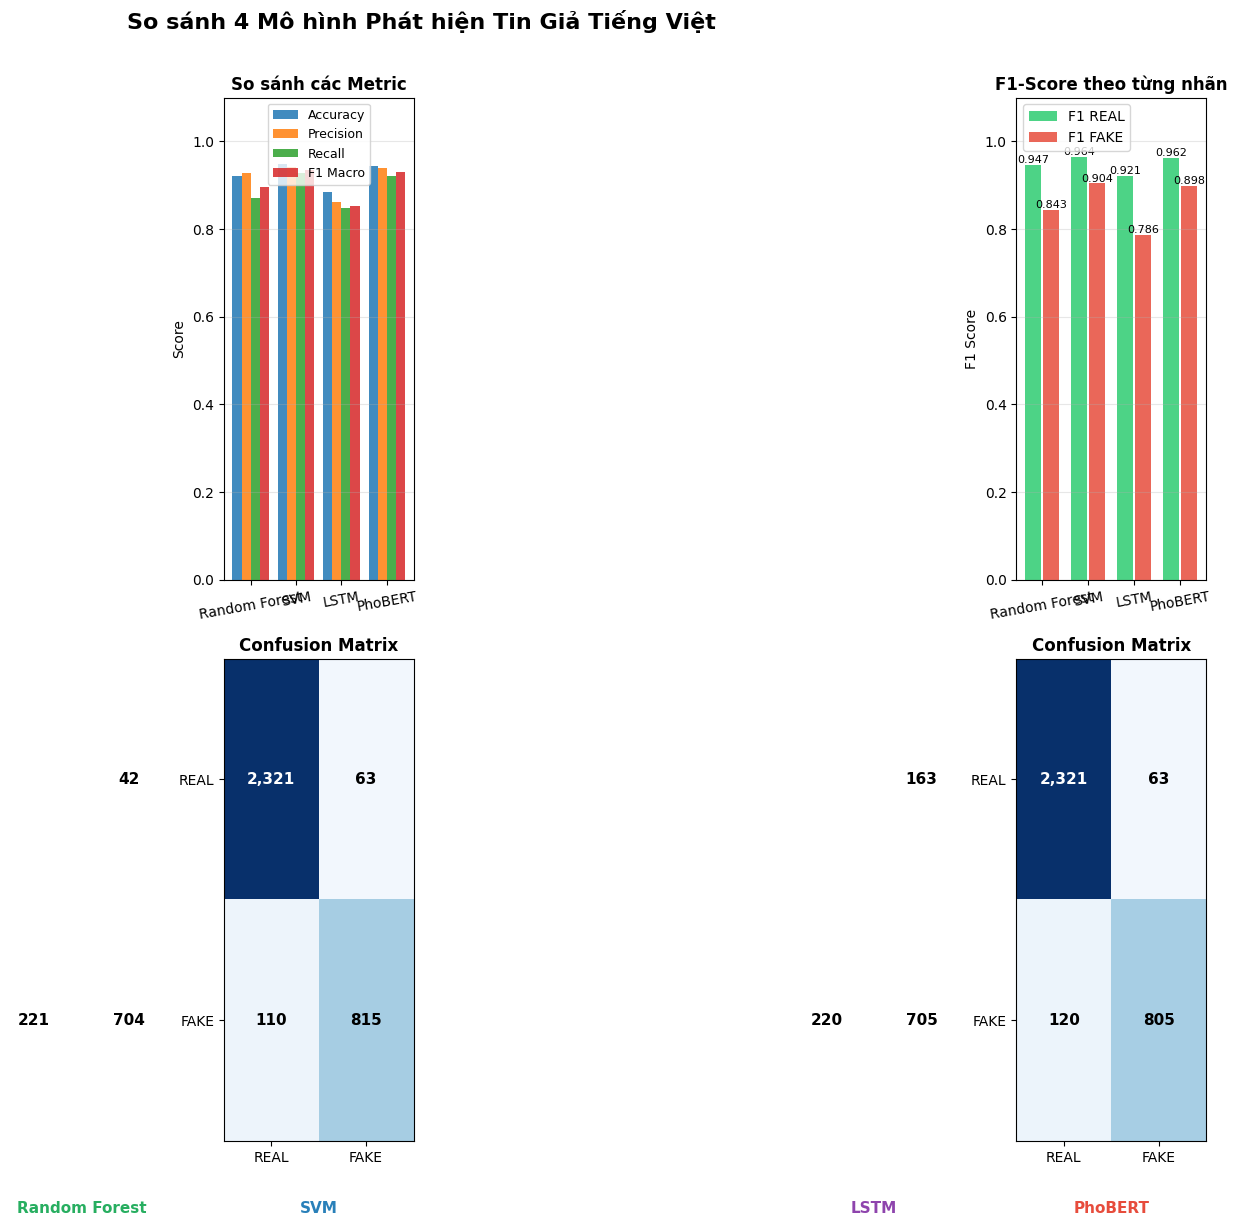


💡 NHẬN XÉT:
   🥇 Tốt nhất  : SVM (F1=0.9341, Acc=0.9477)
   🥉 Thấp nhất : LSTM (F1=0.8535, Acc=0.8843)
   📈 Chênh lệch F1: 0.0806

💾 Đã lưu biểu đồ → /content/data/comparison_results.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import (confusion_matrix, precision_score,
                              recall_score, f1_score, accuracy_score)

print("="*65)
print("🏆 BẢNG SO SÁNH 4 MÔ HÌNH TRÊN TEST SET")
print("="*65)

# Tổng hợp kết quả
models_info = [
    ('Random Forest', rf_preds_test,   '#27ae60'),
    ('SVM',          svm_preds_test,   '#2980b9'),
    ('LSTM',         lstm_preds_test,  '#8e44ad'),
    ('PhoBERT',      bert_preds_test,  '#e74c3c'),
]

results = []
for name, preds, color in models_info:
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro')
    rec  = recall_score(y_test, preds,    average='macro')
    f1   = f1_score(y_test, preds,        average='macro')
    f1_fake = f1_score(y_test, preds, pos_label=1, average='binary')
    results.append({'name': name, 'acc': acc, 'prec': prec,
                    'rec': rec, 'f1': f1, 'f1_fake': f1_fake, 'color': color})

# In bảng so sánh
print(f"\n{'Mô hình':<16} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1 Macro':>10} {'F1 Fake':>10}")
print("─"*65)
best_f1 = max(r['f1'] for r in results)
for r in results:
    mark = ' ⭐' if r['f1'] == best_f1 else ''
    print(f"  {r['name']:<14} {r['acc']:>10.4f} {r['prec']:>10.4f} "
          f"{r['rec']:>10.4f} {r['f1']:>10.4f} {r['f1_fake']:>10.4f}{mark}")

# ── Biểu đồ so sánh ──
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('So sánh 4 Mô hình Phát hiện Tin Giả Tiếng Việt',
             fontsize=16, fontweight='bold', y=1.01)

names  = [r['name']  for r in results]
colors = [r['color'] for r in results]

# 1. Bar chart — 4 metrics
metrics = ['acc', 'prec', 'rec', 'f1']
labels  = ['Accuracy', 'Precision', 'Recall', 'F1 Macro']
x = np.arange(len(names))
width = 0.2

for i, (metric, label) in enumerate(zip(metrics, labels)):
    vals = [r[metric] for r in results]
    bars = axes[0,0].bar(x + i*width, vals, width, label=label, alpha=0.85)

axes[0,0].set_title('So sánh các Metric', fontweight='bold')
axes[0,0].set_xticks(x + width*1.5)
axes[0,0].set_xticklabels(names, rotation=10)
axes[0,0].set_ylim(0, 1.1)
axes[0,0].legend(fontsize=9)
axes[0,0].grid(axis='y', alpha=0.3)
axes[0,0].set_ylabel('Score')

# 2. Bar chart — F1 riêng từng nhãn
f1_real = [f1_score(y_test, r['name'] and [rf_preds_test, svm_preds_test,
           lstm_preds_test, bert_preds_test][i], pos_label=0, average='binary')
           for i, r in enumerate(results)]
f1_fake_list = [r['f1_fake'] for r in results]

x2 = np.arange(len(names))
axes[0,1].bar(x2 - 0.2, f1_real,      0.35, label='F1 REAL', color='#2ecc71', alpha=0.85)
axes[0,1].bar(x2 + 0.2, f1_fake_list, 0.35, label='F1 FAKE', color='#e74c3c', alpha=0.85)
for i, (vr, vf) in enumerate(zip(f1_real, f1_fake_list)):
    axes[0,1].text(i-0.2, vr+0.005, f'{vr:.3f}', ha='center', fontsize=8)
    axes[0,1].text(i+0.2, vf+0.005, f'{vf:.3f}', ha='center', fontsize=8)
axes[0,1].set_title('F1-Score theo từng nhãn', fontweight='bold')
axes[0,1].set_xticks(x2); axes[0,1].set_xticklabels(names, rotation=10)
axes[0,1].set_ylim(0, 1.1); axes[0,1].legend()
axes[0,1].grid(axis='y', alpha=0.3); axes[0,1].set_ylabel('F1 Score')

# 3. Confusion matrices (2x2 grid)
all_preds_list = [rf_preds_test, svm_preds_test, lstm_preds_test, bert_preds_test]
for idx, (r, preds) in enumerate(zip(results, all_preds_list)):
    ax = axes[1, 0] if idx < 2 else axes[1, 1]
    cm = confusion_matrix(y_test, preds)
    if idx % 2 == 0:
        ax.cla()
        ax.set_title('Confusion Matrix', fontweight='bold')

    offset = idx % 2
    im = ax.imshow(cm, cmap='Blues',
                   extent=[offset*2.5, offset*2.5+2, 0, 2],
                   vmin=0, vmax=cm.max(), aspect='auto')
    for i in range(2):
        for j in range(2):
            ax.text(offset*2.5 + j + 0.5, 1.5 - i,
                    f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=11, fontweight='bold',
                    color='white' if cm[i,j] > cm.max()*0.5 else 'black')
    ax.text(offset*2.5 + 1, -0.3, r['name'], ha='center',
            fontsize=11, fontweight='bold', color=r['color'])
    ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['FAKE', 'REAL'])
    if offset == 0:
        ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['REAL', 'FAKE'])
    else:
        ax.set_xticks([3.0, 4.0]); ax.set_xticklabels(['REAL', 'FAKE'])

plt.tight_layout()
plt.savefig('/content/data/comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Nhận xét tự động ──
best = max(results, key=lambda r: r['f1'])
worst = min(results, key=lambda r: r['f1'])
print(f"\n💡 NHẬN XÉT:")
print(f"   🥇 Tốt nhất  : {best['name']} (F1={best['f1']:.4f}, Acc={best['acc']:.4f})")
print(f"   🥉 Thấp nhất : {worst['name']} (F1={worst['f1']:.4f}, Acc={worst['acc']:.4f})")
print(f"   📈 Chênh lệch F1: {best['f1'] - worst['f1']:.4f}")
print("\n💾 Đã lưu biểu đồ → /content/data/comparison_results.png")


## 📥 Xuất kết quả & Tải về

In [ ]:
import json, shutil, pickle
from google.colab import files

print("="*55)
print("💾 XUẤT KẾT QUẢ VÀ LƯU MÔ HÌNH")
print("="*55)

# Lưu bảng so sánh ra CSV
summary = []
all_preds_list = [rf_preds_test, svm_preds_test, lstm_preds_test, bert_preds_test]
model_names    = ['Random Forest', 'SVM', 'LSTM', 'PhoBERT']

for name, preds in zip(model_names, all_preds_list):
    summary.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds, average='macro'), 4),
        'Recall'   : round(recall_score(y_test, preds, average='macro'), 4),
        'F1_Macro' : round(f1_score(y_test, preds, average='macro'), 4),
        'F1_FAKE'  : round(f1_score(y_test, preds, pos_label=1, average='binary'), 4),
        'F1_REAL'  : round(f1_score(y_test, preds, pos_label=0, average='binary'), 4),
    })

df_summary = pd.DataFrame(summary).sort_values('F1_Macro', ascending=False)
csv_path = '/content/data/model_comparison.csv'
df_summary.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n📊 Bảng so sánh:")
print(df_summary.to_string(index=False))
print(f"\n💾 Đã lưu: {csv_path}")

# ═══════════════════════════════════════════════════════════
# LƯU CÁC MÔ HÌNH VÀO GOOGLE DRIVE
# ═══════════════════════════════════════════════════════════
print("\n" + "="*55)
print("📦 LƯU MÔ HÌNH VÀO GOOGLE DRIVE")
print("="*55)

# Tạo thư mục trên Google Drive
drive_models_dir = '/content/drive/MyDrive/FakeNews_Models'
os.makedirs(drive_models_dir, exist_ok=True)
print(f"\n📁 Thư mục lưu trữ: {drive_models_dir}")

# 1. Lưu TF-IDF Vectorizer (dùng chung cho RF và SVM)
print("\n1️⃣  Lưu TF-IDF Vectorizer...")
with open(f'{drive_models_dir}/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("   ✅ tfidf_vectorizer.pkl")

# 2. Lưu Random Forest
print("\n2️⃣  Lưu Random Forest model...")
with open(f'{drive_models_dir}/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print("   ✅ random_forest.pkl")

# 3. Lưu SVM (model tốt nhất cho tiếng Việt)
print("\n3️⃣  Lưu SVM model (BEST cho tiếng Việt)...")
with open(f'{drive_models_dir}/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)
print("   ✅ svm_model.pkl")
print("   📊 Test Accuracy: 94.77% | F1: 0.9341")

# 4. Lưu LSTM model (PyTorch)
print("\n4️⃣  Lưu LSTM model (PyTorch)...")
torch.save({
    'model_state_dict': lstm_model.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'embed_dim': EMBED_DIM,
    'hidden_dim': HIDDEN_DIM,
    'num_layers': NUM_LAYERS,
}, f'{drive_models_dir}/lstm_model.pth')
print("   ✅ lstm_model.pth")

# 5. Lưu LSTM Tokenizer
print("\n5️⃣  Lưu LSTM Tokenizer...")
with open(f'{drive_models_dir}/lstm_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer_lstm, f)
print("   ✅ lstm_tokenizer.pkl")

# 6. Copy PhoBERT model vào Drive
print("\n6️⃣  Copy PhoBERT model vào Drive...")
phobert_drive_dir = f'{drive_models_dir}/phobert_model'
if os.path.exists(phobert_drive_dir):
    shutil.rmtree(phobert_drive_dir)
shutil.copytree(BERT_SAVE_PATH, phobert_drive_dir)
print("   ✅ phobert_model/ (folder)")
print("   📊 Test Accuracy: 94.47% | F1: 0.9300")

# 7. Lưu kết quả so sánh
print("\n7️⃣  Lưu kết quả so sánh...")
shutil.copy('/content/data/model_comparison.csv', f'{drive_models_dir}/model_comparison.csv')
shutil.copy('/content/data/comparison_results.png', f'{drive_models_dir}/comparison_results.png')
print("   ✅ model_comparison.csv")
print("   ✅ comparison_results.png")

# 8. Tạo file README hướng dẫn sử dụng
print("\n8️⃣  Tạo file README...")
readme_content = """# FAKE NEWS DETECTION MODELS

## 📊 Kết quả đánh giá trên Test Set

| Model | Accuracy | F1 Score | Ghi chú |
|-------|----------|----------|----------|
| SVM | 94.77% | 0.9341 | ⭐ Tốt nhất - Nhanh, nhẹ |
| PhoBERT | 94.47% | 0.9300 | Hiểu ngữ cảnh tốt |
| Random Forest | 92.05% | 0.8947 | Cân bằng |
| LSTM | 88.43% | 0.8535 | Deep Learning |

## 📦 Các file trong thư mục

### Models chính (cho web):
- `tfidf_vectorizer.pkl` - TF-IDF vectorizer (dùng chung cho RF và SVM)
- `svm_model.pkl` - ⭐ SVM model (khuyến nghị dùng cho web)
- `random_forest.pkl` - Random Forest model
- `lstm_model.pth` - LSTM model (PyTorch)
- `lstm_tokenizer.pkl` - Tokenizer cho LSTM
- `phobert_model/` - PhoBERT model (folder)

### Kết quả:
- `model_comparison.csv` - Bảng so sánh chi tiết
- `comparison_results.png` - Biểu đồ so sánh

## 💡 Khuyến nghị cho Web Application

### Option 1: SVM (Khuyến nghị) ✅
- **Ưu điểm**: Nhanh, nhẹ, accuracy cao (94.77%)
- **Files cần**: `tfidf_vectorizer.pkl` + `svm_model.pkl`
- **Phù hợp**: Production, server yếu, cần response nhanh

### Option 2: PhoBERT
- **Ưu điểm**: Hiểu ngữ cảnh tốt, accuracy 94.47%
- **Files cần**: `phobert_model/` (folder)
- **Phù hợp**: Server mạnh, cần phân tích sâu

## 🚀 Cách sử dụng trong Flask/FastAPI

```python
import pickle

# Load model
with open('tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
    
with open('svm_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Predict
text = "Tin tức cần kiểm tra..."
X = tfidf.transform([text])
prediction = model.predict(X)[0]
probability = model.predict_proba(X)[0]
```

## 📅 Thông tin
- Dataset: Vietnamese Fake News Dataset
- Training date: 2025
- Framework: Scikit-learn, PyTorch, Transformers
"""

with open(f'{drive_models_dir}/README.md', 'w', encoding='utf-8') as f:
    f.write(readme_content)
print("   ✅ README.md")

# ═══════════════════════════════════════════════════════════
# TẢI VỀ MÁY (TÙY CHỌN)
# ═══════════════════════════════════════════════════════════
print("\n" + "="*55)
print("⬇️  TẢI VỀ MÁY (TÙY CHỌN)")
print("="*55)
print("\n⚠️  Models đã được lưu vào Google Drive.")
print("Bạn có muốn tải về máy không? (y/n)")
print("\nNếu KHÔNG cần tải về, hãy comment dòng files.download() bên dưới.\n")

# Uncomment các dòng dưới nếu muốn tải về máy
# files.download(f'{drive_models_dir}/model_comparison.csv')
# files.download(f'{drive_models_dir}/comparison_results.png')
# files.download(f'{drive_models_dir}/tfidf_vectorizer.pkl')
# files.download(f'{drive_models_dir}/svm_model.pkl')

# ═══════════════════════════════════════════════════════════
# HOÀN TẤT
# ═══════════════════════════════════════════════════════════
print("\n" + "="*55)
print("🎉 HOÀN TẤT!")
print("="*55)
print(f"\n📁 Tất cả models đã được lưu vào:")
print(f"   {drive_models_dir}")
print("\n📦 Danh sách files:")
print("   ✅ tfidf_vectorizer.pkl")
print("   ✅ svm_model.pkl (⭐ Khuyến nghị cho web)")
print("   ✅ random_forest.pkl")
print("   ✅ lstm_model.pth")
print("   ✅ lstm_tokenizer.pkl")
print("   ✅ phobert_model/ (folder)")
print("   ✅ model_comparison.csv")
print("   ✅ comparison_results.png")
print("   ✅ README.md")
print("\n💡 Khuyến nghị cho web:")
print("   🥇 SVM: Nhanh, nhẹ, accuracy 94.77%")
print("   🥈 PhoBERT: Hiểu ngữ cảnh tốt, accuracy 94.47%")
print("\n✨ Truy cập Google Drive để lấy models cho Flask/FastAPI!")


💾 XUẤT KẾT QUẢ

📊 Bảng so sánh:
        Model  Accuracy  Precision  Recall  F1_Macro  F1_FAKE  F1_REAL
          SVM    0.9477     0.9415  0.9273    0.9341   0.9040   0.9641
      PhoBERT    0.9447     0.9391  0.9219    0.9300   0.8979   0.9621
Random Forest    0.9205     0.9287  0.8717    0.8947   0.8426   0.9468
         LSTM    0.8843     0.8610  0.8469    0.8535   0.7864   0.9206

💾 Đã lưu: /content/data/model_comparison.csv

⬇️  Đang tải files về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 HOÀN TẤT! Bạn đã có kết quả so sánh 4 mô hình.
